# NLP Feature Engineering

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE as S
from nltk.corpus import stopwords
import nltk

# Download standard list once
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [90]:
"""Reloading utils module to reflect recent changes without restarting the kernel"""
import importlib
from src import utils

importlib.reload(utils)

<module 'src.utils' from 'd:\\Python PC\\Portfolio Projects\\My Data Science Projects\\ReturnX_Project\\ReturnX-Intelligent-Returns-Classifier\\src\\utils.py'>

In [91]:
# Importing the labeled_reviews.csv file into a pandas DataFrame
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

df = pd.read_csv("../data/interim/labeled2_reviews.csv")

In [92]:
display(df.head())

,index_id,clothing_id,age,review_text,rating,return_category,word_count,age_group
0,0,767,33,Absolutely wonderful - silky and sexy and comf...,4,Other,8,25-34
1,1,1080,34,Love this dress! it's sooo pretty. i happene...,5,Other,62,25-34
2,2,1077,60,I had such high hopes for this dress and reall...,3,Defect,98,55-64
3,3,1049,50,"I love, love, love this jumpsuit. it's fun, fl...",5,Other,22,45-54
4,4,847,47,This shirt is very flattering to all due to th...,5,Other,36,45-54


### Creating the Custom Stop Words list 

In [93]:
# Removing the poisining phrases
POISON_PHRASES: list[str] = [
    "true to size", "true size", "love dress", "love love",
    "fit perfectly", "fits perfectly", "fit great", "just right",
    "looks like", "looks great", "looked like", "look like", "look great",
    "highly recommend", "super cute", "absolutely love", "really wanted",
    "received compliments", "soft comfortable", "material soft", "fabric soft", "super soft",
    "usually wear", "normally wear", "usual size", "wait wear", "easy wear", "fit well", "fits well",
    "well made"
]

# Positive sentiments words to remove
INDIVIDUAL_STOP_WORDS: list[str] = [
    "love", "great", "perfect", "cute", "recommend", "compliments", "comfortable",
    "want", "wanted", "feel", "like", "nice", "good"
]

stop_words: set[str] = set(stopwords.words("english"))

negations: set[str] = {"no", "not", "nor", "neither", "never", "none"}

final_stop_words: list[str] = list(stop_words - negations)

# Add our domain-specific positive stop words
final_stop_words.extend(INDIVIDUAL_STOP_WORDS)

print(f"Stop words count: {len(final_stop_words)}")
print(f"'not' in stop_words? {'not' in final_stop_words}") # Should be False

Stop words count: 208
'not' in stop_words? False


### Designing the Cleaning Function

In [94]:
def clean_review_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # Remove Poison Phrases from the text
    for phrase in POISON_PHRASES:
        # Replace with space
        text = re.sub(re.escape(phrase), "", text)


    words: list[str] = text.split()
    words_cleaned: list[str] = []
    
    for word in words:
        if (word not in final_stop_words) or (word in negations):
            words_cleaned.append(word)
    
    text = " ".join(words_cleaned)


    # Remove special chars but KEEP numbers
    # Keeping letters, numbers and basic punctuation
    text = re.sub(r"[^a-z0-9\s]", "", text)

    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Applying the cleaning function to the "review_text" column
df["clean_text"] = df["review_text"].apply(clean_review_text)

# Check the difference
print("Original:", df.iloc[0]["review_text"])
print("Cleaned:",  df.iloc[0]["clean_text"])

Original: Absolutely wonderful - silky and sexy and comfortable
Cleaned: absolutely wonderful silky sexy


In [95]:
display(df.head())

,index_id,clothing_id,age,review_text,rating,return_category,word_count,age_group,clean_text
0,0,767,33,Absolutely wonderful - silky and sexy and comf...,4,Other,8,25-34,absolutely wonderful silky sexy
1,1,1080,34,Love this dress! it's sooo pretty. i happene...,5,Other,62,25-34,dress sooo pretty happened find store glad bc ...
2,2,1077,60,I had such high hopes for this dress and reall...,3,Defect,98,55-64,high hopes dress work me initially ordered pet...
3,3,1049,50,"I love, love, love this jumpsuit. it's fun, fl...",5,Other,22,45-54,love love jumpsuit fun flirty fabulous every t...
4,4,847,47,This shirt is very flattering to all due to th...,5,Other,36,45-54,shirt flattering due adjustable front tie leng...


### Verifying the Bi-Grams in the cleandd text

Visualizing Bigrams for Category: Defect


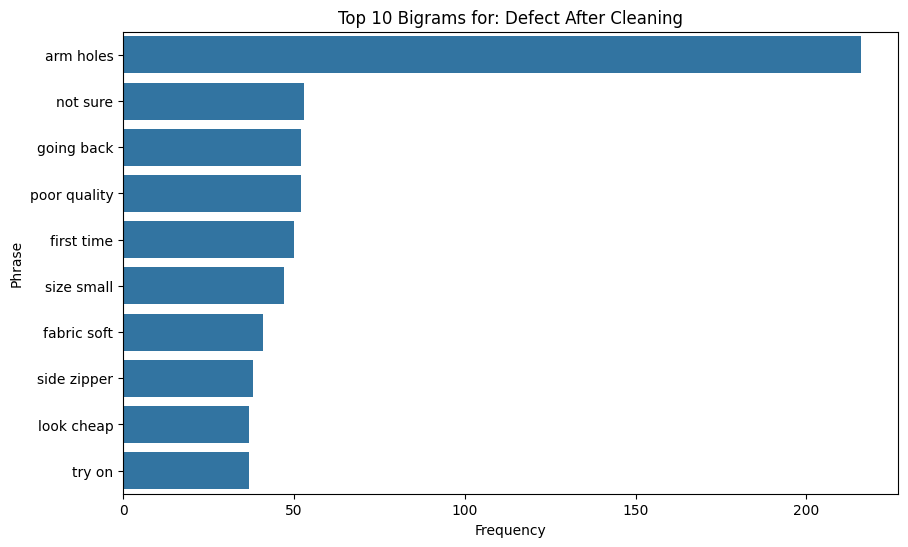

Visualizing Bigrams for Category: Sizing


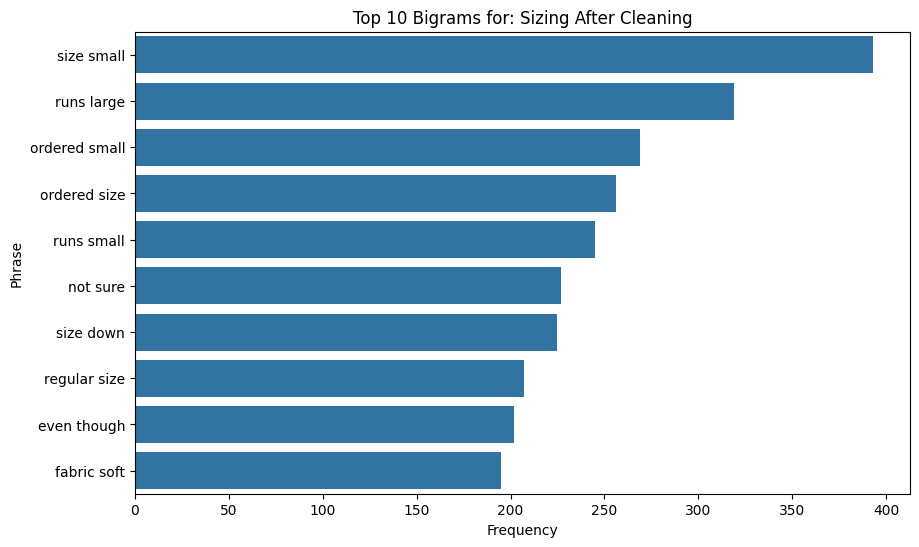

In [96]:
from src.utils import visualize_ngrams_clean as vng_c


cats = ["Defect", "Sizing"]
# cats = df["return_category"].unique().tolist()

for cat in cats:
    print(f"Visualizing Bigrams for Category: {cat}")
    vng_c(df, cat)

### Performing TF-IDF Vectorization

In [97]:
# Initializing our Vectorizer
# - ngram_range=(1,2): Capture unigrams ("broken") and bigrams ("zipper broke")
# - min_df=5: Ignore words that appear in less than 5 reviews (Typo filtering)
# - stop_words: Our custom list that KEEPS "not"

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    stop_words=final_stop_words,
    min_df=5
)

# Create the Feature Matrix 

In [98]:
df.dtypes

index_id            int64
clothing_id         int64
age                 int64
review_text        object
rating              int64
return_category    object
word_count          int64
age_group          object
clean_text         object
dtype: object